In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.options.display.float_format = '{:.6f}'.format


In [39]:
filename = "../data/BTCUSDT_hourly.csv"

In [40]:
def view_data(df):
    print(df.head(10))

In [41]:
def n_month_rolling(n, df):
    """create n month rolling window column: ..."YYYY-01"... """
    return df["timestamp"].dt.year.astype(str) + "-" + (df["timestamp"].dt.month // n * n + 1).astype(str).str.zfill(2) 

def load_data(filename):
    df = pd.read_csv(filename)
    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1)) / np.log(df["Close"])
    std_val = df["log_return"].std()
    # Define labels based on 1-hour interval price movement
    df["label"] = 0  # Default class (no significant movement)
    df.loc[df["log_return"] >= std_val, "label"] = 1  # Uptrend
    df.loc[df["log_return"] <= -std_val, "label"] = -1  # Downtrend
    
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["period"] = n_month_rolling(3, df)

    
    df.dropna(inplace=True)
    return df


df = load_data(filename)
df.head()

returns = df["log_return"]


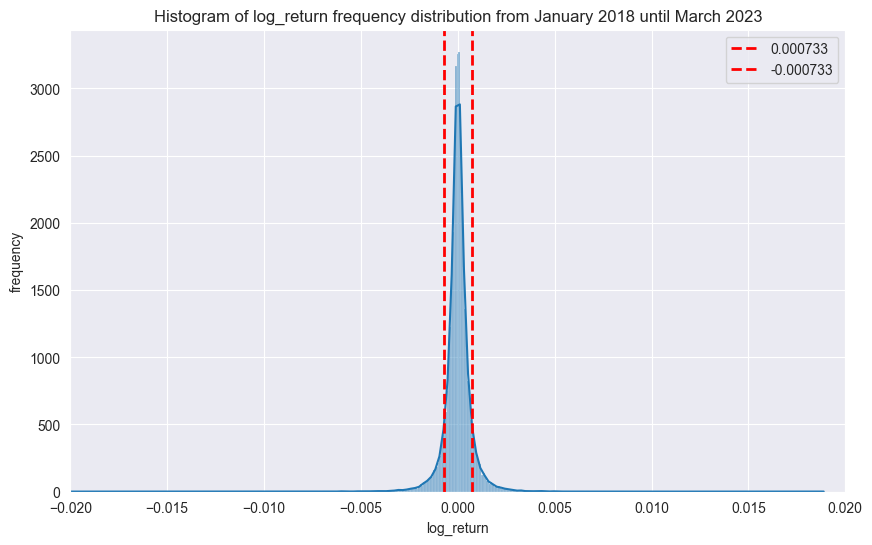

In [43]:
#plot frequency distribution
std_val = round(returns.std(),6)
plt.figure(figsize=(10, 6))
sns.histplot(returns, bins=550, kde=True)
plt.xlim([-0.02, 0.02])
plt.axvline(x=std_val, color='red', linestyle='--', linewidth=2, label=str(std_val))
plt.axvline(x=-std_val, color='red', linestyle='--', linewidth=2, label=str(-std_val))
plt.xlabel("log_return")
plt.ylabel("frequency")
plt.title("Histogram of log_return frequency distribution from January 2018 until March 2023")
plt.legend()
plt.show()

Positive return 13 times out of 22 periods or 59.09%


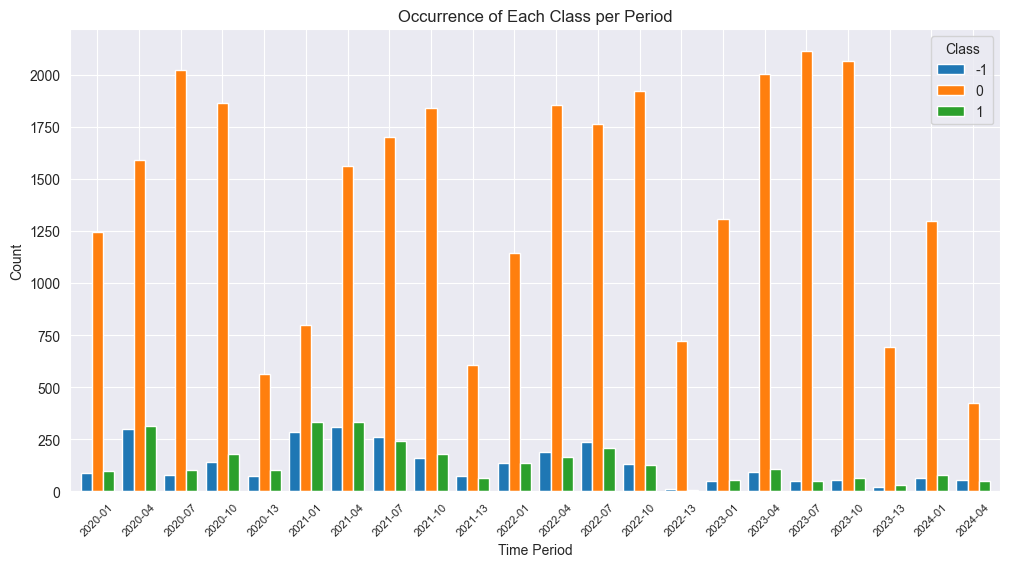

In [36]:
# Count occurrences per class per period
class_counts = df.groupby(["period", "label"]).size().unstack()
one_wins_count = (class_counts[1] > class_counts[-1]).sum() #go over column values
all_count = len(class_counts)
print(f"Positive return {one_wins_count} times out of {all_count} periods or {one_wins_count/all_count * 100:.2f}%")
# Plot grouped bar chart
class_counts.plot(kind="bar", figsize=(12, 6), width=0.8)
plt.xlabel("Time Period")
plt.ylabel("Count")
plt.title("Occurrence of Each Class per Period")
plt.legend(title="Class")
plt.xticks(rotation=45, fontsize=8)
plt.show()

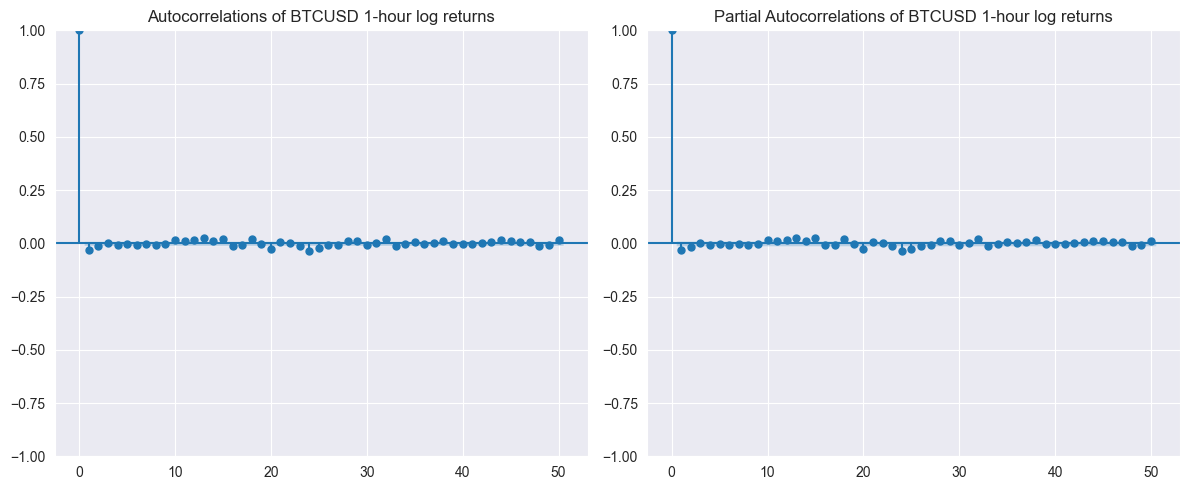

In [37]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Autocorrelation plot (ACF)
plot_acf(returns, lags=50, ax=axes[0])
axes[0].set_title("Autocorrelations of BTCUSD 1-hour log returns")

# Partial Autocorrelation plot (PACF)
plot_pacf(returns, lags=50, ax=axes[1])
axes[1].set_title("Partial Autocorrelations of BTCUSD 1-hour log returns")

plt.tight_layout()
plt.show()
